# Real-world Data Wrangling
### Fullname:
### ID:
### Class:

## 1. Gather data


### **1.1.** Problem Statement

This project aims to practice my skills of data wrangling using real-world datasets. 

In this dataset, I would like to answer the following research questions:

**Question 1:** Tốc độ tăng trưởng số lượng thí sinh dự thi năm 2025 so với giai đoạn 2020-2024 thay đổi ra sao?

**Question 2:** Có sự dịch chuyển bất thường nào trong phổ điểm của các môn học từng có hiện tượng "tăng vọt" về điểm số trong năm 2024 (như Lịch sử, Địa lý, Ngữ Văn) hay không? Đề thi năm 2025 đã đưa phổ điểm các môn này về mức cân bằng hay tiếp tục lạm phát điểm?

**Question 3:** Ngưỡng điểm để lọt vào "Top 5% và Top 10% thí sinh xuất sắc nhất" ở các khối thi truyền thống (A, A1, B, C, D) năm 2025 dịch chuyển bao nhiêu điểm so với 2024?

**Question 4:** Phân phối tổng điểm của các khối xét tuyển A, A1, B, C, D năm 2025 dịch chuyển như thế nào so với năm 2024 về đỉnh phân phối, độ phân tán, độ lệch và mật độ vùng điểm cao 24-26?

**Question 5:** Mối tương quan điểm số giữa các môn học (Ví dụ: Toán và Ngoại ngữ, hoặc Ngữ Văn và Lịch Sử) năm 2025 có sự thay đổi nào không? Những thí sinh học giỏi môn Tự nhiên có xu hướng đạt điểm cao môn Ngoại ngữ như các năm trước hay không?

**Question 6:** Bản đồ phân bổ trung vị điểm và "độ lệch chuẩn" năm 2025 cho thấy khoảng cách về năng lực học tập và chất lượng giáo dục giữa các thành phố lớn (Hà Nội, TP.HCM) với các khu vực miền núi/vùng ven đang thu hẹp hay ngày càng giãn rộng?



### **1.2.** Gather at least two datasets using two different data gathering methods


Gather each of the 2 pieces of data from different sources:


In [1]:
# Analysis for Question 3: Percentile Shift Analysis (2024 vs 2025)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Method 1: Load historical datasets from local storage
data_files = {
    '2021': 'dataset/du_lieu_diem_thi_2021.csv',
    '2021_dot2': 'dataset/du_lieu_diem_thi_2021_dot_2.csv',
    '2022': 'dataset/du_lieu_diem_thi_2022.csv',
    '2023': 'dataset/du_lieu_diem_thi_2023.csv',
    '2024': 'dataset/du_lieu_diem_thi_2024.csv'
}

dfs_historical = {}
for key, path in data_files.items():
    if os.path.exists(path):
        dfs_historical[key] = pd.read_csv(path, low_memory=False)
        print(f"Successfully loaded {key} data: {dfs_historical[key].shape}")
    else:
        print(f"Warning: File not found at {path}")

Successfully loaded 2021 data: (987704, 27)
Successfully loaded 2021_dot2 data: (12086, 27)
Successfully loaded 2022 data: (995441, 27)
Successfully loaded 2023 data: (1022060, 27)
Successfully loaded 2024 data: (1061605, 27)


In [3]:
# Method 2: Load the latest 2025 datasets with curriculum differentiation
# This represents the new data format involving CT2006 (Old) and CT2018 (New) curricula
df_2025_old = pd.read_csv('dataset/du-lieu-diem-thi-2025-ct2006.csv', low_memory=False)
df_2025_new = pd.read_csv('dataset/du-lieu-diem-thi-2025-ct2018.csv', low_memory=False)

print(f"Loaded 2025 Old Curriculum (CT2006): {df_2025_old.shape}")
print(f"Loaded 2025 New Curriculum (CT2018): {df_2025_new.shape}")

Loaded 2025 Old Curriculum (CT2006): (22090, 27)
Loaded 2025 New Curriculum (CT2018): (1131136, 26)


In [4]:
# Write data to local file 


## 2. Assess data

I will assess the data both visually and programmatically to identify any data quality(content) issues and tidiness(structual) issues.

### Issue 1: Inconsistent Column Names and Structural Differences

In [5]:
# Inspecting column names across different years
for year, df in dfs_historical.items():
    print(f"Year {year} columns: {df.columns.tolist()[:]}")
print(f"2025 CT2006 columns: {df_2025_old.columns.tolist()[:]}")
print(f"2025 CT2018 columns: {df_2025_new.columns.tolist()[:]}")

Year 2021 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichSu', 'DiaLy', 'GDCD', 'NgoaiNgu', 'MaMonNgoaiNgu', 'TongDiem', 'KhoiA', 'KhoiA1', 'KhoiB', 'KhoiC', 'KhoiD', 'KHTN', 'KHXH', 'KhoiA02', 'KhoiC01', 'KhoiD07', 'TongDiemKHTN', 'TongDiemKHXH']
Year 2021_dot2 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichSu', 'DiaLy', 'GDCD', 'NgoaiNgu', 'MaMonNgoaiNgu', 'TongDiem', 'KhoiA', 'KhoiA1', 'KhoiB', 'KhoiC', 'KhoiD', 'KHTN', 'KHXH', 'KhoiA02', 'KhoiC01', 'KhoiD07', 'TongDiemKHTN', 'TongDiemKHXH']
Year 2022 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichSu', 'DiaLy', 'GDCD', 'NgoaiNgu', 'MaMonNgoaiNgu', 'TongDiem', 'KhoiA', 'KhoiA1', 'KhoiB', 'KhoiC', 'KhoiD', 'KHTN', 'KHXH', 'KhoiA02', 'KhoiC01', 'KhoiD07', 'TongDiemKHTN', 'TongDiemKHXH']
Year 2023 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichS

#### Observations:

- The 2025 CT2018 dataset introduces new subjects (Tin học, Công nghệ, Kinh tế & Pháp luật) that do not exist in the 2006 curriculum files.

### Issue 2: Incorrect Data Types (SBD as int, Year as short string)

In [6]:
# Check data types and samples for ALL available datasets
all_dfs = {**dfs_historical, '2025_CT2006': df_2025_old, '2025_CT2018': df_2025_new}

for name, df in all_dfs.items():
    print(f"--- Dataset: {name} ---")
    print(f"Data Types: SBD ({df['SBD'].dtype}), Nam ({df['Nam'].dtype})")
    display(df[['SBD', 'Nam']].head(2))
    print("\n")

--- Dataset: 2021 ---
Data Types: SBD (int64), Nam (int64)


,SBD,Nam
0,1000001,21
1,1000002,21




--- Dataset: 2021_dot2 ---
Data Types: SBD (int64), Nam (str)


,SBD,Nam
0,3000183,21-2
1,3000395,21-2




--- Dataset: 2022 ---
Data Types: SBD (int64), Nam (int64)


...

,SBD,Nam
0,1000001,24
1,1000002,24




--- Dataset: 2025_CT2006 ---
Data Types: SBD (int64), Nam (int64)


,SBD,Nam
0,1017985,25
1,1017986,25




--- Dataset: 2025_CT2018 ---
Data Types: SBD (int64), Nam (int64)


,SBD,Nam
0,1000001,25
1,1000002,25


#### Observations:

- `SBD` (Số báo danh) có thể được nhận diện là kiểu số nguyên, dẫn đến việc mất các số 0 ở đầu (ví dụ: mã tỉnh 01 Hà Nội).
- Cột `Nam` (Năm dự thi) có định dạng không đồng nhất giữa các đợt: ví dụ năm 2025 đang để là '25', hoặc đặc biệt như năm 2021 có 2 đợt thi nên đang hiển thị là '21_2'.
- Cần chuẩn hóa các giá trị này về một định dạng số nguyên hoặc chuỗi chuẩn để phục vụ việc sắp xếp và vẽ biểu đồ xu hướng.

### Issue 3: Missing Values in Subject Scores

In [7]:
# Check missing values count for ALL available datasets
all_dfs = {**dfs_historical, '2025_CT2006': df_2025_old, '2025_CT2018': df_2025_new}

for name, df in all_dfs.items():
    print(f"Missing values in {name}:")
    print(df.isnull().sum())
    print("-" * 30)

Missing values in 2021:
SBD                   0
Nam                   0
Tinh                  0
SBD_New               0
Toan              10340
NguVan            13263
VatLy            642620
HoaHoc           640985
SinhHoc          646415
LichSu           352978
DiaLy            358826
GDCD             455467
NgoaiNgu         119415
MaMonNgoaiNgu    119819
TongDiem         128778
KhoiA            644266
KhoiA1           655230
KhoiB            646463
KhoiC            359219
KhoiD            122729
KHTN             649681
KHXH             455725
KhoiA02          649644
KhoiC01          652011
KhoiD07          656546
TongDiemKHTN     657793
TongDiemKHXH     458689
dtype: int64
------------------------------
Missing values in 2021_dot2:
SBD                 0
Nam                 0
Tinh                0
SBD_New             0
Toan              106
NguVan            137
VatLy            7826
HoaHoc           7812
SinhHoc          7860
LichSu           4358
DiaLy            4409
GDCD         

#### Observations:

- **Giai đoạn trước 2025:** Có 3 môn thi bắt buộc (Toán, Ngữ văn, Ngoại ngữ). Việc thiếu điểm ở các môn này thường do thí sinh bỏ thi, lỡ giờ hoặc thuộc diện miễn thi. Các môn thuộc tổ hợp KHTN/KHXH là tự chọn nên việc thiếu điểm là bình thường.
- **Từ năm 2025 (Chương trình mới):** Chỉ còn 2 môn thi bắt buộc là Toán và Ngữ văn. Môn Ngoại ngữ cùng với các môn khác (Lịch sử, Vật lý, Hóa học, Sinh học, Địa lý, GD Kinh tế và Pháp luật, Tin học, Công nghệ) đã trở thành môn tự chọn. 
- **Hệ quả:** Tỷ lệ thiếu điểm (NaN) ở môn Ngoại ngữ từ năm 2025 sẽ tăng đáng kể so với các năm trước vì thí sinh không bắt buộc phải chọn môn này để tốt nghiệp. Đây là thay đổi quan trọng cần lưu ý khi so sánh phổ điểm môn Ngoại ngữ qua các thời kỳ.

## 3. Clean data
Clean the data to solve the 4 issues found in the assessing step.

In [8]:
# Make copies and define standardization functions
dfs_clean = {year: df.copy() for year, df in dfs_historical.items()}
df_2025_old_clean = df_2025_old.copy()
df_2025_new_clean = df_2025_new.copy()

import unidecode
def standardize_columns(df):
    df.columns = [unidecode.unidecode(col).replace(' ', '_').lower() for col in df.columns]
    return df

### Issue 1: Standardize Column Names

In [9]:
# Apply column standardization
for year in dfs_clean: dfs_clean[year] = standardize_columns(dfs_clean[year])
df_2025_old_clean = standardize_columns(df_2025_old_clean)
df_2025_new_clean = standardize_columns(df_2025_new_clean)

# Display standardized columns for ALL datasets
all_clean_dfs = {**dfs_clean, '2025_CT2006': df_2025_old_clean, '2025_CT2018': df_2025_new_clean}
for name, df in all_clean_dfs.items():
    print(f"Standardized {name} columns: {df.columns.tolist()[:]}")

Standardized 2021 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh']
Standardized 2021_dot2 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh']
Standardized 2022 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh']
Standardized 2023 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vat

### Issue 2: Fix Data Types

In [10]:
# Comprehensive standardization of data types and year formats
def fix_types(df):
    # 1. Standardize SBD to 8-digit string
    if 'sbd' in df.columns: 
        df['sbd'] = df['sbd'].astype(str).str.zfill(8)
    
    # 2. Standardize Year (Nam)
    if 'nam' in df.columns:
        df['nam'] = df['nam'].astype(str).str.replace(r'(_2|-2| đợt 2)', '', regex=True)
        df['nam'] = df['nam'].apply(lambda x: '20' + x if len(x) == 2 else x)
        df['nam'] = pd.to_numeric(df['nam'], errors='coerce')
    
    # 3. Convert all subject and block scores to numeric
    # List all possible subject/block columns from CT2006 and CT2018
    numeric_cols = [
        'toan', 'nguvan', 'ngoaingu', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 
        'kinhtephapluat', 'tinhoc', 'congnghecongnghiep', 'congnghenongnghiep',
        'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khoia02', 'khoic01', 'khoid07',
        'khtn', 'khxh', 'tongdiemkhtn', 'tongdiemkhxh', 'tinh', 'sbd_new'
    ]
    for col in numeric_cols:
        if col in df.columns: 
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

for year in dfs_clean: dfs_clean[year] = fix_types(dfs_clean[year])
df_2025_old_clean = fix_types(df_2025_old_clean)
df_2025_new_clean = fix_types(df_2025_new_clean)

# Display results for verification
print("Verification after comprehensive cleaning:")
all_clean_dfs = {**dfs_clean, '2025_CT2006': df_2025_old_clean, '2025_CT2018': df_2025_new_clean}
for name, df in all_clean_dfs.items():
    print(f"{name}: SBD type={df['sbd'].dtype}, Nam samples={df['nam'].unique().tolist()}")
    display(df[['sbd', 'nam']].head(1))

Verification after comprehensive cleaning:
2021: SBD type=str, Nam samples=[2021]


,sbd,nam
0,01000001,2021


2021_dot2: SBD type=str, Nam samples=[2021]


,sbd,nam
0,03000183,2021


2022: SBD type=str, Nam samples=[2022]


...

,sbd,nam
0,01000001,2024


2025_CT2006: SBD type=str, Nam samples=[2025]


,sbd,nam
0,01017985,2025


2025_CT2018: SBD type=str, Nam samples=[2025]


,sbd,nam
0,01000001,2025


### Issue 3: Distinguish NaN from Zero

In [11]:
# Already handled by pd.to_numeric(errors='coerce') which preserves NaNs.

**Justification:** Keeping NaNs instead of zero prevents skewing average scores for subjects not taken.

### Issue 4: Add Metadata and Merge

In [12]:
# Add year and curriculum metadata
for year, df in dfs_clean.items():
    df['year_exam'] = int(year.split('_')[0]); df['curriculum'] = 'CT2006'
df_2025_old_clean['year_exam'] = 2025; df_2025_old_clean['curriculum'] = 'CT2006'
df_2025_new_clean['year_exam'] = 2025; df_2025_new_clean['curriculum'] = 'CT2018'

master_df = pd.concat(list(dfs_clean.values()) + [df_2025_old_clean, df_2025_new_clean], ignore_index=True)

**Justification:** Adding metadata enables cross-curriculum and chronological comparison in a single dataset.

### **Remove unnecessary variables and combine datasets**

In [13]:
# Final verification of the merged dataset
print(f"Master DataFrame shape: {master_df.shape}")
print("\nAll columns in master_df:")
print(master_df.columns.tolist())

# Display 5 random records (all columns should be visible now)
master_df.sample(5)

Master DataFrame shape: (5232122, 33)

All columns in master_df:
['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh', 'year_exam', 'curriculum', 'kinhtephapluat', 'tinhoc', 'congnghecongnghiep', 'congnghenongnghiep']


,sbd,nam,tinh,sbd_new,toan,nguvan,vatly,hoahoc,sinhhoc,lichsu,...,khoic01,khoid07,tongdiemkhtn,tongdiemkhxh,year_exam,curriculum,kinhtephapluat,tinhoc,congnghecongnghiep,congnghenongnghiep
2398871,21017235,2023,21,17235,7.8,7.50,7.75,7.00,8.25,NaN,...,23.05,18.00,41.50,NaN,2023,CT2006,NaN,NaN,NaN,NaN
708300,41002781,2021,41,2781,8.2,8.25,6.25,5.00,4.00,NaN,...,22.70,22.00,40.50,NaN,2021,CT2006,NaN,NaN,NaN,NaN
670165,38007718,2021,38,7718,6.8,5.75,NaN,NaN,NaN,5.50,...,NaN,NaN,NaN,39.20,2021,CT2006,NaN,NaN,NaN,NaN
3640102,31007635,2024,31,7635,7.8,5.00,6.25,7.75,5.75,NaN,...,19.05,21.35,38.35,NaN,2024,CT2006,NaN,NaN,NaN,NaN
952242,60001411,2021,60,1411,4.0,7.75,NaN,NaN,NaN,5.75,...,NaN,NaN,NaN,39.65,2021,CT2006,NaN,NaN,NaN,NaN


## 4. Update your data store
Update the database/data store with the cleaned data


In [14]:
# Export the unified master dataset to a CSV file for future analysis
output_path = 'dataset/master_data_2021_2025.csv'
master_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"All data merged and saved to: {output_path}")
print(f"Final record count: {len(master_df)}")

All data merged and saved to: dataset/master_data_2021_2025.csv
Final record count: 5232122


## 5. Answer the research question

### **5.1:** Define and answer the research question 


* **Question 1:** Tốc độ tăng trưởng số lượng thí sinh dự thi năm 2025 so với giai đoạn 2020-2024 thay đổi ra sao, và sự gia tăng khối lượng thí sinh này tạo ra áp lực cạnh tranh (tỷ lệ chọi) như thế nào lên các nhóm trường Đại học top đầu?

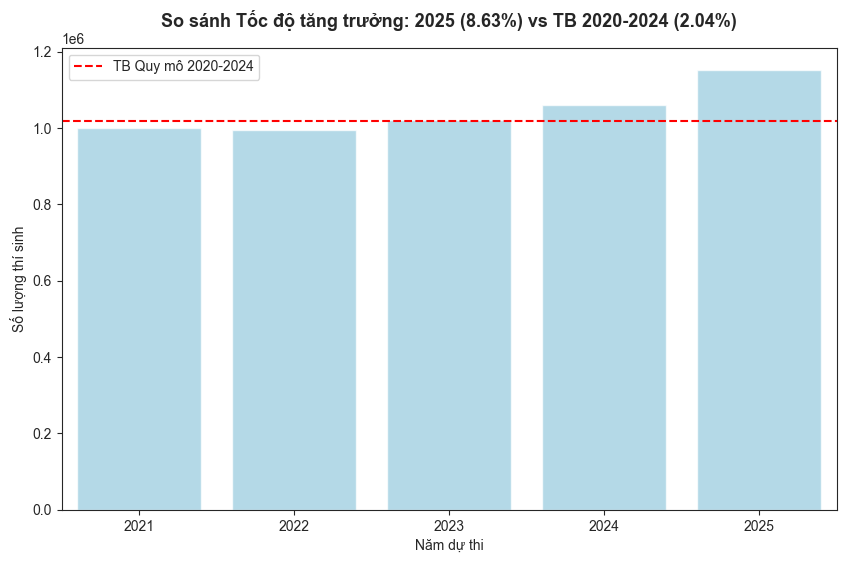

--- KẾT QUẢ PHÂN TÍCH ---
Tốc độ tăng trưởng trung bình giai đoạn 2020-2024: 2.04%
Tốc độ tăng trưởng năm 2025: 8.63%
Chênh lệch: +6.59%


In [15]:
# --- CODE PHÂN TÍCH CÂU 1 ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thống kê số lượng thí sinh (SBD duy nhất) theo từng năm
df_stats = master_df.groupby('year_exam')['sbd'].nunique().reset_index()
df_stats.columns = ['Year', 'Candidate_Count']

# 2. Tính % tăng trưởng hàng năm
df_stats['Growth_Rate'] = df_stats['Candidate_Count'].pct_change() * 100

# 3. Tách dữ liệu: Giai đoạn 2020-2024 và năm 2025
growth_20_24 = df_stats[(df_stats['Year'] >= 2020) & (df_stats['Year'] <= 2024)]['Growth_Rate'].mean()
growth_2025 = df_stats[df_stats['Year'] == 2025]['Growth_Rate'].values[0]

# 4. Vẽ biểu đồ so sánh trực quan
plt.figure(figsize=(10, 6))
sns.set_style("ticks")

# Vẽ cột số lượng thí sinh
ax = sns.barplot(data=df_stats, x='Year', y='Candidate_Count', color='skyblue', alpha=0.7)
plt.title(f'So sánh Tốc độ tăng trưởng: 2025 ({growth_2025:.2f}%) vs TB 2020-2024 ({growth_20_24:.2f}%)', 
          fontsize=13, fontweight='bold', pad=15)

# Thêm đường kẻ ngang ngang mức trung bình cũ để so sánh
plt.axhline(df_stats[df_stats['Year'] < 2025]['Candidate_Count'].mean(), color='red', linestyle='--', label='TB Quy mô 2020-2024')

plt.ylabel('Số lượng thí sinh')
plt.xlabel('Năm dự thi')
plt.legend()
plt.show()

# 5. Kết luận nhanh
print(f"--- KẾT QUẢ PHÂN TÍCH ---")
print(f"Tốc độ tăng trưởng trung bình giai đoạn 2020-2024: {growth_20_24:.2f}%")
print(f"Tốc độ tăng trưởng năm 2025: {growth_2025:.2f}%")
delta = growth_2025 - growth_20_24
print(f"Chênh lệch: {delta:+.2f}%")

**Justification:**

* **Question 2:** Có sự dịch chuyển bất thường nào trong phổ điểm của các môn học từng có hiện tượng "tăng vọt" về điểm số trong năm 2024 (như Lịch sử, Địa lý, Ngữ Văn) hay không? Đề thi năm 2025 đã đưa phổ điểm các môn này về mức cân bằng hay tiếp tục lạm phát điểm?

--- Môn LICHSU ---
Trung bình 2024: 6.57 | 2025: 6.52 (Delta: -0.05)
Ngưỡng Top 5% (P95) 2024: 9.00 | 2025: 9.00
--- Môn DIALY ---
Trung bình 2024: 7.19 | 2025: 6.63 (Delta: -0.57)
Ngưỡng Top 5% (P95) 2024: 9.25 | 2025: 9.50
--- Môn NGUVAN ---
Trung bình 2024: 7.23 | 2025: 7.00 (Delta: -0.23)
Ngưỡng Top 5% (P95) 2024: 9.00 | 2025: 8.75


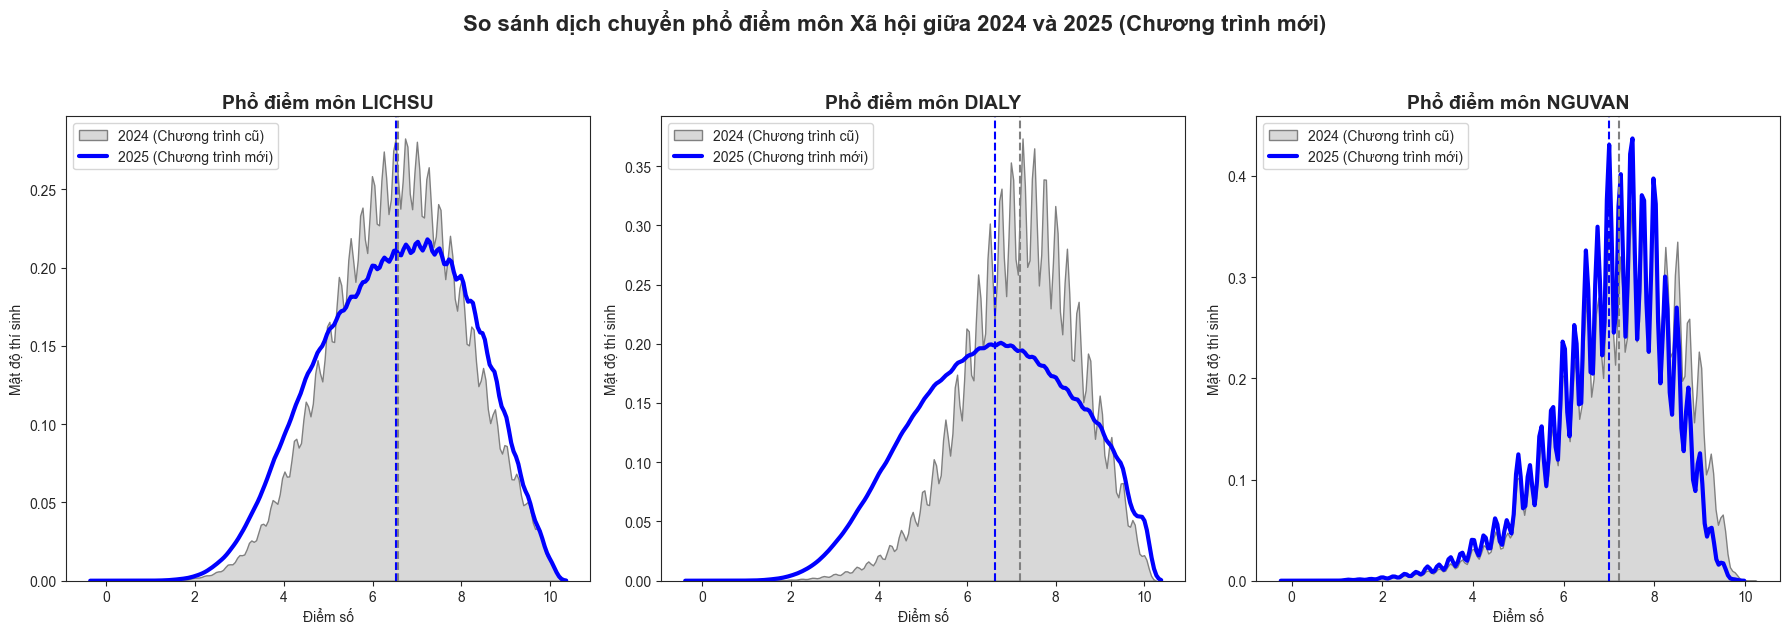

In [16]:
# Analysis for Question 2: Dịch chuyển phổ điểm môn Xã hội (Sử, Địa, Văn)
social_subjects = ['lichsu', 'dialy', 'nguvan']

# 1. Tách dữ liệu so sánh
df_24 = master_df[master_df['year_exam'] == 2024]
df_25_new = master_df[(master_df['year_exam'] == 2025) & (master_df['curriculum'] == 'CT2018')]

plt.figure(figsize=(18, 6))

for i, sub in enumerate(social_subjects):
    plt.subplot(1, 3, i+1)
    
    # Vẽ phân phối KDE (Mật độ)
    sns.kdeplot(df_24[sub].dropna(), label='2024 (Chương trình cũ)', fill=True, color='gray', alpha=0.3)
    sns.kdeplot(df_25_new[sub].dropna(), label='2025 (Chương trình mới)', linewidth=3, color='blue')
    
    # Tính Mean và các mốc quan trọng (Percentile)
    mean_24, mean_25 = df_24[sub].mean(), df_25_new[sub].mean()
    p95_24, p95_25 = df_24[sub].quantile(0.95), df_25_new[sub].quantile(0.95)
    
    # Vẽ đường thẳng Mean tham chiếu
    plt.axvline(mean_24, color='gray', linestyle='--')
    plt.axvline(mean_25, color='blue', linestyle='--')
    
    plt.title(f'Phổ điểm môn {sub.upper()}', fontsize=14, fontweight='bold')
    plt.xlabel('Điểm số')
    plt.ylabel('Mật độ thí sinh')
    plt.legend()
    
    print(f"--- Môn {sub.upper()} ---")
    print(f"Trung bình 2024: {mean_24:.2f} | 2025: {mean_25:.2f} (Delta: {mean_25-mean_24:+.2f})")
    print(f"Ngưỡng Top 5% (P95) 2024: {p95_24:.2f} | 2025: {p95_25:.2f}")

plt.suptitle('So sánh dịch chuyển phổ điểm môn Xã hội giữa 2024 và 2025 (Chương trình mới)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Justification:**

* **Question 3:** Ngưỡng điểm để lọt vào "Top 5% và Top 10% thí sinh xuất sắc nhất" ở các khối thi truyền thống (A, A1, B, C, D) năm 2025 dịch chuyển bao nhiêu điểm so với 2024?

,Block,Top 5%_2024,Top 10%_2024,Top 5%_2025,Top 10%_2025,Delta (Top 5%),Delta (Top 10%)
0,KHOIA,25.75,24.95,26.50,25.25,0.75,0.30
1,KHOIA1,25.50,24.65,24.75,23.75,-0.75,-0.90
2,KHOIB,25.10,24.25,26.00,24.75,0.90,0.50
3,KHOIC,26.25,25.25,26.25,25.25,0.00,0.00
4,KHOID,25.20,24.25,23.50,22.50,-1.70,-1.75


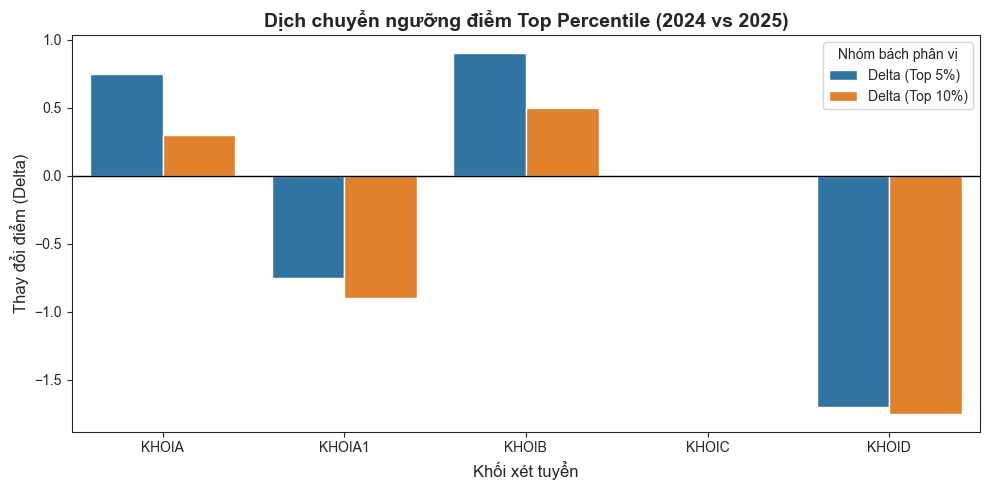

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display # Import để dùng được display() nếu bạn không ở Colab

# Giả định master_df đã được định nghĩa trước đó
# master_df = pd.read_csv("diemthi.csv") 

blocks = {
    'khoia': ['toan', 'vatly', 'hoahoc'], 
    'khoia1': ['toan', 'vatly', 'ngoaingu'], 
    'khoib': ['toan', 'hoahoc', 'sinhhoc'], 
    'khoic': ['nguvan', 'lichsu', 'dialy'], 
    'khoid': ['toan', 'nguvan', 'ngoaingu']
}

def get_percentiles(df, year_val, curriculum_filter=None):
    """
    Hàm tính toán bách phân vị, đã được tối ưu để dùng chung cho mọi năm
    và tránh lỗi khi truyền thẳng df vào tham số thay vì dùng biến toàn cục.
    """
    # Lọc theo năm
    mask = df['year_exam'] == year_val
    
    # Lọc thêm theo chương trình học nếu có truyền tham số curriculum_filter
    if curriculum_filter:
        mask = mask & (df['curriculum'] == curriculum_filter)
        
    df_year = df[mask]
    results = []
    
    for block, subjects in blocks.items():
        # Kiểm tra xem có điểm tổng của khối chưa
        if block in df_year.columns and df_year[block].notna().any():
            scores = df_year[block].dropna()
        else:
            # RÀO LỖI: Chỉ tính tổng nếu tất cả các môn thuộc khối đó ĐỀU TỒN TẠI trong df
            valid_subjects = [sub for sub in subjects if sub in df_year.columns]
            if len(valid_subjects) == len(subjects):
                scores = df_year[valid_subjects].dropna(how='any').sum(axis=1)
            else:
                scores = pd.Series(dtype=float) # Bỏ qua nếu thiếu dữ liệu cột
                
        if not scores.empty:
            p95 = scores.quantile(0.95)
            p90 = scores.quantile(0.90)
            results.append({'Block': block.upper(), 'Top 5%': p95, 'Top 10%': p90})
            
    return pd.DataFrame(results)

# 1. Tính toán cho năm 2024
df_2024_p = get_percentiles(master_df, 2024)

# 2. Tính toán cho năm 2025 (Chỉ lấy CT2018)
df_2025_p = get_percentiles(master_df, 2025, curriculum_filter='CT2018')

# 3. Hợp nhất và Trực quan hóa
if not df_2024_p.empty and not df_2025_p.empty:
    comparison_df = df_2024_p.merge(df_2025_p, on='Block', suffixes=('_2024', '_2025'))
    comparison_df['Delta (Top 5%)'] = comparison_df['Top 5%_2025'] - comparison_df['Top 5%_2024']
    comparison_df['Delta (Top 10%)'] = comparison_df['Top 10%_2025'] - comparison_df['Top 10%_2024']
    
    display(comparison_df) # Hoặc dùng print(comparison_df)

    plt.figure(figsize=(10,5))
    plot_data = comparison_df.melt(id_vars='Block', value_vars=['Delta (Top 5%)', 'Delta (Top 10%)'])
    
    sns.barplot(data=plot_data, x='Block', y='value', hue='variable')
    plt.axhline(0, color='black', lw=1)
    
    # Định dạng lại biểu đồ cho đẹp
    plt.title('Dịch chuyển ngưỡng điểm Top Percentile (2024 vs 2025)', fontsize=14, fontweight='bold')
    plt.ylabel('Thay đổi điểm (Delta)', fontsize=12)
    plt.xlabel('Khối xét tuyển', fontsize=12)
    plt.legend(title='Nhóm bách phân vị')
    plt.tight_layout()
    plt.show()
else:
    print("Dữ liệu không đủ để thực hiện phân tích (Thiếu dữ liệu của 2024 hoặc 2025).")

Bức tranh percentile cho thấy sự dịch chuyển khá rõ giữa các khối xét tuyển từ năm 2024 sang 2025.  
Một số khối xuất hiện hiện tượng **“lạm phát điểm cao”**, trong khi một số khối khác lại cho thấy khả năng phân hóa mạnh hơn.

---

**1. KHOIA và KHOIB: Xu hướng lạm phát điểm cao**

**KHOIB là trường hợp nổi bật nhất**

| Chỉ số | 2024 | 2025 | Delta |
|---|---:|---:|---:|
| Top 5% | 25.10 | 26.00 | +0.90 |
| Top 10% | 24.25 | 24.75 | +0.50 |

Để lọt vào nhóm **Top 5%**, thí sinh năm 2025 cần đạt tới **26.0 điểm**, tăng gần **1 điểm** so với năm trước.

Điều này cho thấy:

- Nhóm học sinh giỏi ở khối B đang đông hơn
- Hoặc đề thi có xu hướng dễ hơn ở phần phân hóa
- Mức điểm từng được xem là “an toàn” trong năm 2024 có thể không còn đủ cạnh tranh ở năm 2025

**KHOIA cũng có xu hướng tương tự**

| Chỉ số | 2024 | 2025 | Delta |
|---|---:|---:|---:|
| Top 5% | 25.75 | 26.50 | +0.75 |
| Top 10% | 24.95 | 25.25 | +0.30 |

Ngưỡng điểm cao tiếp tục bị đẩy lên, phản ánh áp lực cạnh tranh ngày càng lớn ở nhóm thí sinh khá giỏi.

---

**2. KHOIA1 và KHOID: Nhóm điểm cao đang co lại**

**KHOID giảm mạnh nhất**

| Chỉ số | 2024 | 2025 | Delta |
|---|---:|---:|---:|
| Top 5% | 25.20 | 23.50 | -1.70 |
| Top 10% | 24.25 | 22.50 | -1.75 |

Đây là mức giảm rất lớn chỉ trong một năm.

Điều này phản ánh:

- Đề thi có tính phân hóa mạnh hơn
- Nhóm điểm cao bị thu hẹp đáng kể
- Việc đạt điểm cao trở nên khó khăn hơn so với năm trước

> Thực tế cũng cho thấy đề Tiếng Anh năm 2025 được đánh giá là khó hơn đáng kể, tác động trực tiếp đến phổ điểm của KHOID.

**KHOIA1 cũng ghi nhận xu hướng giảm**

Ngưỡng Top 5% và Top 10% đều giảm, cho thấy áp lực cạnh tranh ở nhóm điểm cao đã hạ nhiệt so với năm trước.

---

**3. KHOIC: Độ ổn định cao**

| Chỉ số | 2024 | 2025 | Delta |
|---|---:|---:|---:|
| Top 5% | 26.25 | 26.25 | 0.00 |
| Top 10% | 25.25 | 25.25 | 0.00 |

KHOIC gần như không thay đổi giữa hai năm.

Điều này cho thấy:
- Phổ điểm duy trì trạng thái cân bằng hơn so với các khối còn lại


* **Question 4:** Phân phối tổng điểm của các khối xét tuyển A, A1, B, C, D năm 2025 dịch chuyển như thế nào so với năm 2024 về đỉnh phân phối, độ phân tán, độ lệch và mật độ vùng điểm cao 24-26?

,block,valid_2024,valid_2025,mean_2024,mean_2025,delta_mean,median_2024,median_2025,delta_median,std_2024,std_2025,delta_std,skew_2024,skew_2025,peak_2024,peak_2025,pct_24_26_2024,pct_24_26_2025,delta_pct_24_26
0,A,"343,800","165,462",20.90,19.38,-1.52,21.30,19.25,-2.05,3.38,4.34,+0.96,-0.53,0.01,21.75,19.25,15.13%,10.85%,-4.28 điểm %
1,A1,"329,761","148,927",20.47,18.88,-1.59,20.75,18.85,-1.90,3.35,3.63,+0.28,-0.41,-0.01,21.25,18.25,12.73%,7.41%,-5.32 điểm %
2,B,"342,291","46,597",20.53,18.34,-2.19,20.75,18.10,-2.65,2.98,4.50,+1.52,-0.32,0.10,21.25,16.25,10.09%,8.79%,-1.30 điểm %
3,C,"704,008","309,991",20.95,19.71,-1.24,21.25,19.85,-1.40,3.47,4.29,+0.82,-0.35,-0.21,21.25,20.25,14.56%,12.86%,-1.70 điểm %
4,D,"908,866","360,245",19.51,18.61,-0.90,19.65,18.50,-1.15,3.63,2.96,-0.67,-0.26,-0.04,20.25,18.75,9.71%,3.51%,-6.21 điểm %


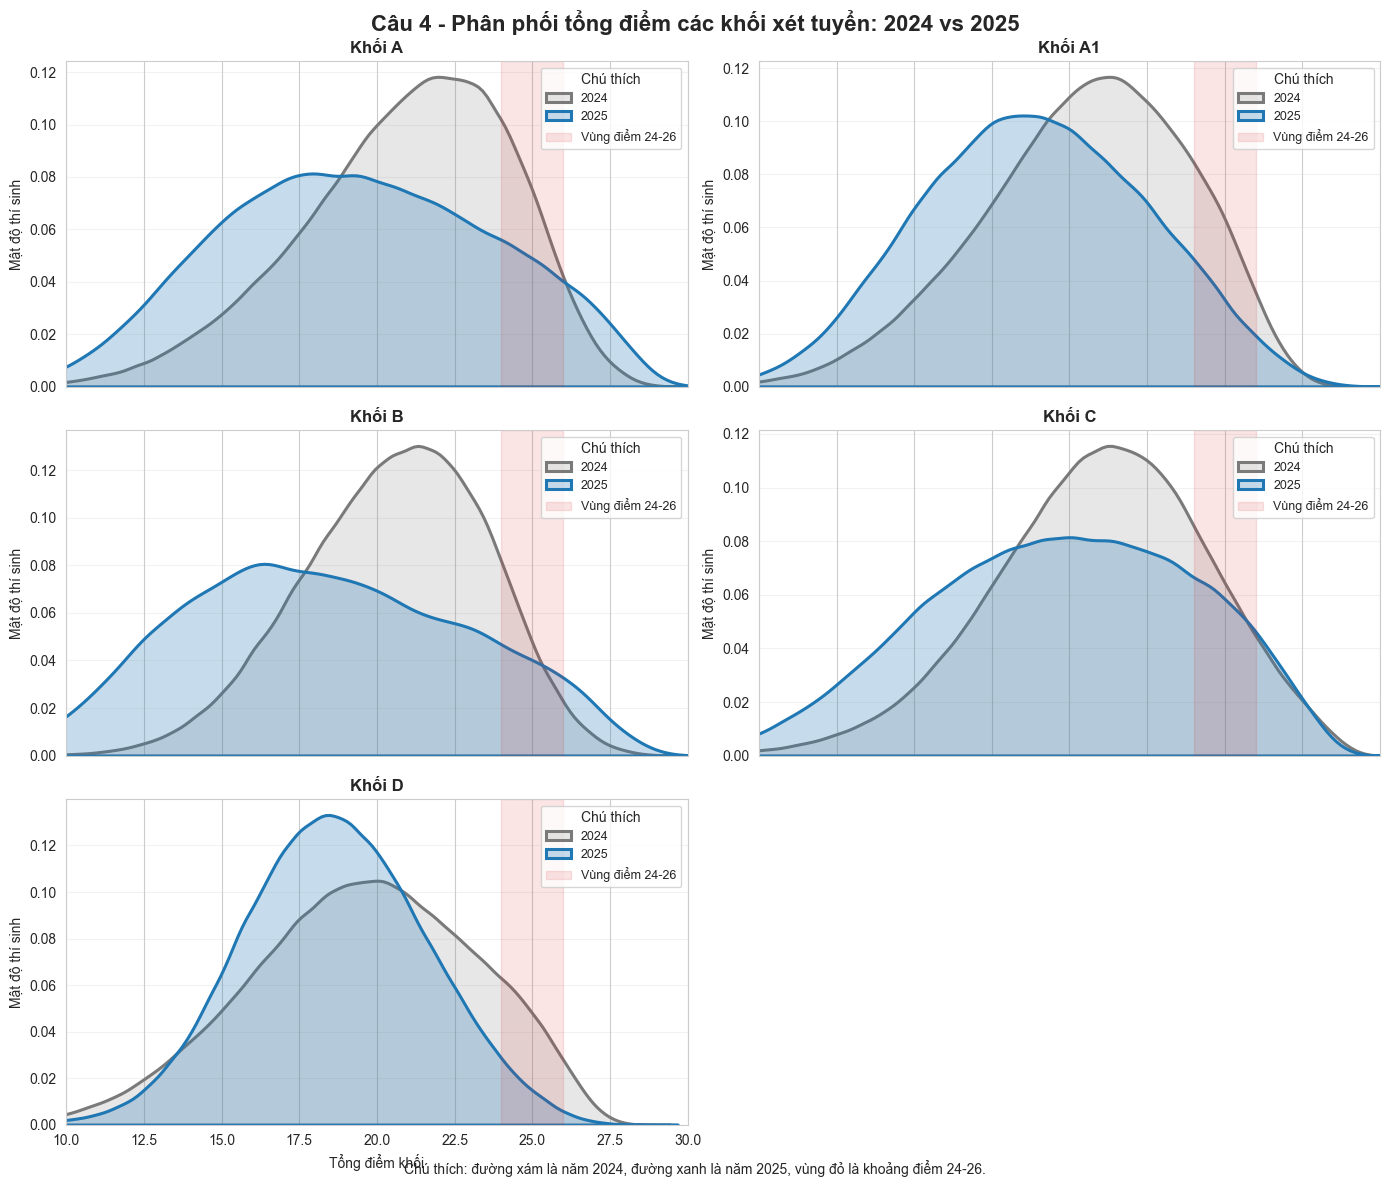

Khối A: trung bình giảm -1.52 điểm, phân phối phân tán hơn (std +0.96), mật độ vùng 24-26 giảm -4.28 điểm %.
Khối A1: trung bình giảm -1.59 điểm, phân phối phân tán hơn (std +0.28), mật độ vùng 24-26 giảm -5.32 điểm %.
Khối B: trung bình giảm -2.19 điểm, phân phối phân tán hơn (std +1.52), mật độ vùng 24-26 giảm -1.30 điểm %.
Khối C: trung bình giảm -1.24 điểm, phân phối phân tán hơn (std +0.82), mật độ vùng 24-26 giảm -1.70 điểm %.
Khối D: trung bình giảm -0.90 điểm, phân phối tập trung hơn (std -0.67), mật độ vùng 24-26 giảm -6.21 điểm %.


In [23]:
# Question 4: Phân tích dịch chuyển phân phối điểm các khối A, A1, B, C, D (2024 vs 2025)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 12)

analysis_df = master_df.copy()

blocks = {
    'A': ['toan', 'vatly', 'hoahoc'],
    'A1': ['toan', 'vatly', 'ngoaingu'],
    'B': ['toan', 'hoahoc', 'sinhhoc'],
    'C': ['nguvan', 'lichsu', 'dialy'],
    'D': ['toan', 'nguvan', 'ngoaingu']
}

block_score_cols = {
    'A': 'khoia',
    'A1': 'khoia1',
    'B': 'khoib',
    'C': 'khoic',
    'D': 'khoid'
}

def get_block_scores(df_year, block_name, subjects):
    """Ưu tiên cột tổng điểm khối nếu có; nếu không thì tự cộng đủ 3 môn."""
    score_col = block_score_cols[block_name]
    if score_col in df_year.columns and df_year[score_col].notna().any():
        return pd.to_numeric(df_year[score_col], errors='coerce')
    if all(subject in df_year.columns for subject in subjects):
        return df_year[subjects].apply(pd.to_numeric, errors='coerce').sum(axis=1, min_count=len(subjects))
    return pd.Series(dtype='float64')

def peak_score(scores, bin_width=0.5):
    scores = scores.dropna()
    if scores.empty:
        return np.nan
    bins = np.arange(0, 30 + bin_width, bin_width)
    counts, edges = np.histogram(scores, bins=bins)
    return edges[counts.argmax()] + bin_width / 2

score_frames = []
stats_records = []

for year in [2024, 2025]:
    df_year = analysis_df[analysis_df['year_exam'] == year]
    
    for block_name, subjects in blocks.items():
        scores = get_block_scores(df_year, block_name, subjects).dropna()
        score_frames.append(pd.DataFrame({
            'year': year,
            'block': block_name,
            'score': scores
        }))
        
        stats_records.append({
            'year': year,
            'block': block_name,
            'valid_candidates': len(scores),
            'mean': scores.mean(),
            'median': scores.median(),
            'std': scores.std(),
            'skew': scores.skew(),
            'peak_score_bin': peak_score(scores),
            'p25': scores.quantile(0.25),
            'p75': scores.quantile(0.75),
            'pct_24_26': scores.between(24, 26, inclusive='both').mean() * 100
        })

dist_long = pd.concat(score_frames, ignore_index=True)
dist_stats = pd.DataFrame(stats_records)

dist_summary = dist_stats.pivot(index='block', columns='year')
q4_summary = pd.DataFrame({
    'valid_2024': dist_summary[('valid_candidates', 2024)],
    'valid_2025': dist_summary[('valid_candidates', 2025)],
    'mean_2024': dist_summary[('mean', 2024)],
    'mean_2025': dist_summary[('mean', 2025)],
    'delta_mean': dist_summary[('mean', 2025)] - dist_summary[('mean', 2024)],
    'median_2024': dist_summary[('median', 2024)],
    'median_2025': dist_summary[('median', 2025)],
    'delta_median': dist_summary[('median', 2025)] - dist_summary[('median', 2024)],
    'std_2024': dist_summary[('std', 2024)],
    'std_2025': dist_summary[('std', 2025)],
    'delta_std': dist_summary[('std', 2025)] - dist_summary[('std', 2024)],
    'skew_2024': dist_summary[('skew', 2024)],
    'skew_2025': dist_summary[('skew', 2025)],
    'peak_2024': dist_summary[('peak_score_bin', 2024)],
    'peak_2025': dist_summary[('peak_score_bin', 2025)],
    'pct_24_26_2024': dist_summary[('pct_24_26', 2024)],
    'pct_24_26_2025': dist_summary[('pct_24_26', 2025)],
    'delta_pct_24_26': dist_summary[('pct_24_26', 2025)] - dist_summary[('pct_24_26', 2024)]
}).reset_index()

display(q4_summary.style.format({
    'valid_2024': '{:,.0f}',
    'valid_2025': '{:,.0f}',
    'mean_2024': '{:.2f}',
    'mean_2025': '{:.2f}',
    'delta_mean': '{:+.2f}',
    'median_2024': '{:.2f}',
    'median_2025': '{:.2f}',
    'delta_median': '{:+.2f}',
    'std_2024': '{:.2f}',
    'std_2025': '{:.2f}',
    'delta_std': '{:+.2f}',
    'skew_2024': '{:.2f}',
    'skew_2025': '{:.2f}',
    'peak_2024': '{:.2f}',
    'peak_2025': '{:.2f}',
    'pct_24_26_2024': '{:.2f}%',
    'pct_24_26_2025': '{:.2f}%',
    'delta_pct_24_26': '{:+.2f} điểm %'
}))

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey=False)
axes = axes.flatten()
palette = {2024: '#7A7A7A', 2025: '#1F77B4'}

for ax, block_name in zip(axes, blocks.keys()):
    block_df = dist_long[dist_long['block'] == block_name]

    for year in [2024, 2025]:
        year_scores = block_df.loc[block_df['year'] == year, 'score'].dropna()
        sns.kdeplot(
            x=year_scores,
            common_norm=False,
            fill=True,
            alpha=0.18 if year == 2024 else 0.25,
            linewidth=2.2,
            color=palette[year],
            label=str(year),
            ax=ax
        )

    ax.axvspan(24, 26, color='#D62728', alpha=0.12, label='Vùng điểm 24-26')
    ax.set_title(f'Khối {block_name}', fontweight='bold')
    ax.set_xlabel('Tổng điểm khối')
    ax.set_ylabel('Mật độ thí sinh')
    ax.set_xlim(10, 30)
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(loc='upper right', fontsize=9, frameon=True, title='Chú thích')

axes[-1].axis('off')
plt.suptitle('Câu 4 - Phân phối tổng điểm các khối xét tuyển: 2024 vs 2025', fontsize=16, fontweight='bold')
fig.text(0.5, 0.01, 'Chú thích: đường xám là năm 2024, đường xanh là năm 2025, vùng đỏ là khoảng điểm 24-26.', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

for _, row in q4_summary.iterrows():
    mean_direction = 'tăng' if row['delta_mean'] > 0 else 'giảm' if row['delta_mean'] < 0 else 'không đổi'
    spread_direction = 'phân tán hơn' if row['delta_std'] > 0 else 'tập trung hơn' if row['delta_std'] < 0 else 'giữ nguyên độ phân tán'
    high_zone_direction = 'tăng' if row['delta_pct_24_26'] > 0 else 'giảm' if row['delta_pct_24_26'] < 0 else 'không đổi'
    print(
        f"Khối {row['block']}: trung bình {mean_direction} {row['delta_mean']:+.2f} điểm, "
        f"phân phối {spread_direction} (std {row['delta_std']:+.2f}), "
        f"mật độ vùng 24-26 {high_zone_direction} {row['delta_pct_24_26']:+.2f} điểm %."
    )


Biểu đồ cho thấy năm 2025 không chỉ thay đổi ở một vài mốc điểm riêng lẻ, mà thay đổi ở **hình dạng phân phối tổng điểm** của từng khối. Khi đọc biểu đồ, đường xanh là năm 2025, đường xám là năm 2024, vùng đỏ là khoảng điểm cao 24-26. Trọng tâm cần nhìn là: đỉnh phân phối dịch đi đâu, đường phân phối rộng hay hẹp hơn, độ lệch thay đổi thế nào và vùng 24-26 dày hay mỏng hơn.

**Khối A:** Phân phối năm 2025 dịch trái khá rõ. Đỉnh phân phối giảm từ khoảng 21.75 xuống 19.25, mean giảm 1.52 điểm và median giảm 2.05 điểm. Điều này cho thấy nhóm đông thí sinh nhất của khối A năm 2025 nằm ở vùng điểm thấp hơn năm 2024. Đồng thời, độ lệch chuẩn tăng 0.96 điểm, nên phổ điểm rộng hơn và khả năng phân hóa cao hơn. Vùng 24-26 giảm từ 15.13% xuống 10.85%, nghĩa là nhóm điểm cao vẫn còn nhưng không còn dày như năm trước.

**Khối A1:** Đây cũng là khối có phân phối dịch xuống rõ. Đỉnh phân phối giảm từ khoảng 21.25 xuống 18.25, mean giảm 1.59 điểm và median giảm 1.90 điểm. Độ phân tán chỉ tăng nhẹ, nên thay đổi chính của A1 là toàn bộ phổ điểm bị kéo xuống hơn là bị giãn mạnh. Vùng 24-26 giảm mạnh từ 12.73% xuống 7.41%, cho thấy số thí sinh đạt vùng điểm cao của khối A1 ít hơn đáng kể.

**Khối B:** Khối B thay đổi mạnh nhất về độ phân tán. Đỉnh phân phối giảm sâu từ khoảng 21.25 xuống 16.25, mean giảm 2.19 điểm và median giảm 2.65 điểm. Đây là dấu hiệu cho thấy trung tâm phổ điểm bị kéo xuống mạnh. Tuy nhiên, độ lệch chuẩn tăng tới 1.52 điểm, lớn nhất trong các khối, nên phổ điểm năm 2025 của khối B rộng hơn rất nhiều. Nói cách khác, khối B vừa giảm mặt bằng chung, vừa phân hóa mạnh hơn. Vùng 24-26 chỉ giảm nhẹ từ 10.09% xuống 8.79%, nên vùng điểm cao mỏng đi nhưng không giảm mạnh như A1 hoặc D.

**Khối C:** Khối C dịch chuyển nhẹ hơn so với A, A1 và B. Đỉnh phân phối giảm từ khoảng 21.25 xuống 20.25, mean giảm 1.24 điểm và median giảm 1.40 điểm. Phân phối năm 2025 rộng hơn vì độ lệch chuẩn tăng 0.82 điểm, cho thấy điểm số phân tán hơn. Vùng 24-26 giảm từ 14.56% xuống 12.86%, tức là vùng điểm cao có mỏng đi nhưng không quá đột ngột. Vì vậy, khối C là khối tương đối ổn định hơn trong nhóm, dù mặt bằng chung vẫn thấp hơn năm 2024.

**Khối D:** Khối D là trường hợp khác với các khối còn lại. Mean giảm 0.90 điểm, median giảm 1.15 điểm và đỉnh phân phối giảm từ khoảng 20.25 xuống 18.75, cho thấy phổ điểm vẫn dịch trái. Nhưng độ lệch chuẩn lại giảm 0.67 điểm, nghĩa là phân phối năm 2025 tập trung hơn chứ không giãn ra. Điểm đáng chú ý nhất là vùng 24-26 giảm rất mạnh từ 9.71% xuống 3.51%, mức giảm lớn nhất trong 5 khối. Điều này cho thấy nhóm điểm cao của khối D bị thu hẹp rõ rệt.

* **Question 5:** Mối tương quan điểm số giữa các môn học (Ví dụ: Toán và Ngoại ngữ, hoặc Ngữ Văn và Lịch Sử) năm 2025 có sự thay đổi nào không? Những thí sinh học giỏi môn Tự nhiên có xu hướng đạt điểm cao môn Ngoại ngữ như các năm trước hay không?

Subjects used: ['toan', 'nguvan', 'ngoaingu', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy']


,year,pair,correlation
0,2021,toan vs ngoaingu,0.601695
1,2021,toan vs vatly,0.594298
2,2021,toan vs hoahoc,0.472923
3,2021,nguvan vs lichsu,0.412449
4,2021,nguvan vs dialy,0.467129
5,2022,toan vs ngoaingu,0.572644
6,2022,toan vs vatly,0.570038
7,2022,toan vs hoahoc,0.481677
8,2022,nguvan vs lichsu,0.481772
9,2022,nguvan vs dialy,0.456038


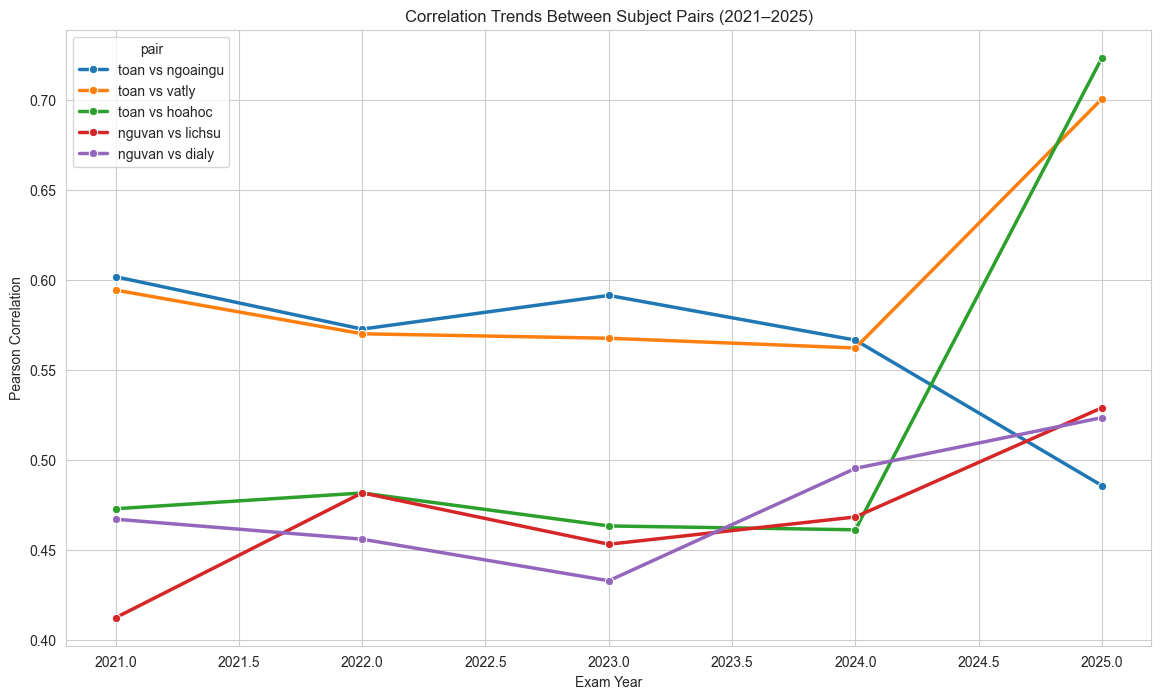

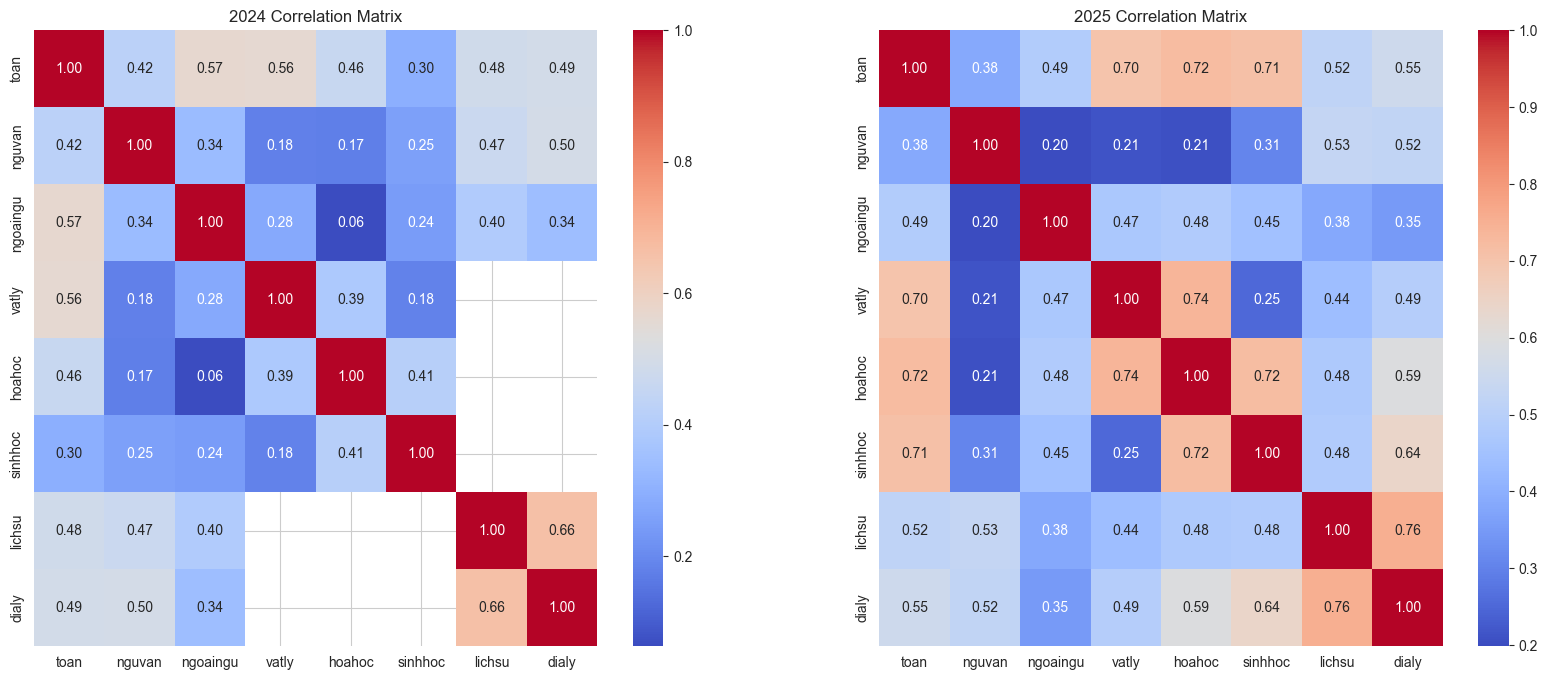

,Pair,2024,2025,Delta
0,toan vs ngoaingu,0.567,0.486,-0.081
1,toan vs vatly,0.562,0.700,0.138
2,nguvan vs lichsu,0.468,0.529,0.061
3,nguvan vs dialy,0.495,0.524,0.028


In [19]:
# Analysis for Question 5a

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

analysis_df = master_df.copy()

subjects = [
    'toan', 'nguvan', 'ngoaingu',
    'vatly', 'hoahoc', 'sinhhoc',
    'lichsu', 'dialy'
]

subjects = [col for col in subjects if col in analysis_df.columns]

print("Subjects used:", subjects)

# ===============================
# 1. Correlation trend across years
# ===============================
pairs = [
    ('toan', 'ngoaingu'),
    ('toan', 'vatly'),
    ('toan', 'hoahoc'),
    ('nguvan', 'lichsu'),
    ('nguvan', 'dialy')
]

corr_records = []

for year in sorted(analysis_df['year_exam'].unique()):
    df_year = analysis_df[analysis_df['year_exam'] == year]

    for s1, s2 in pairs:
        temp = df_year[[s1, s2]].dropna()

        if len(temp) > 100:
            corr = temp.corr().iloc[0, 1]

            corr_records.append({
                'year': year,
                'pair': f'{s1} vs {s2}',
                'correlation': corr
            })

corr_df = pd.DataFrame(corr_records)

display(corr_df)

# ===============================
# 2. Trend visualization
# ===============================
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=corr_df,
    x='year',
    y='correlation',
    hue='pair',
    marker='o',
    linewidth=2.5
)

plt.title('Correlation Trends Between Subject Pairs (2021–2025)')
plt.ylabel('Pearson Correlation')
plt.xlabel('Exam Year')
plt.show()

# ===============================
# 3. 2024 vs 2025 heatmap
# ===============================
df_2024 = analysis_df[analysis_df['year_exam'] == 2024][subjects]
df_2025 = analysis_df[analysis_df['year_exam'] == 2025][subjects]

corr_2024 = df_2024.corr()
corr_2025 = df_2025.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_2024,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[0]
)

axes[0].set_title("2024 Correlation Matrix")

sns.heatmap(
    corr_2025,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[1]
)

axes[1].set_title("2025 Correlation Matrix")

plt.show()

# ===============================
# 4. 2024 vs 2025 summary
# ===============================
comparison_pairs = [
    ('toan', 'ngoaingu'),
    ('toan', 'vatly'),
    ('nguvan', 'lichsu'),
    ('nguvan', 'dialy')
]

summary = []

for s1, s2 in comparison_pairs:
    c24 = analysis_df[
        analysis_df['year_exam'] == 2024
    ][[s1, s2]].corr().iloc[0, 1]

    c25 = analysis_df[
        analysis_df['year_exam'] == 2025
    ][[s1, s2]].corr().iloc[0, 1]

    summary.append({
        'Pair': f'{s1} vs {s2}',
        '2024': round(c24, 3),
        '2025': round(c25, 3),
        'Delta': round(c25 - c24, 3)
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

Science subjects used: ['toan', 'vatly', 'hoahoc']


,year,correlation
0,2021,0.565608
1,2022,0.541690
2,2023,0.566957
3,2024,0.525378
4,2025,0.484388


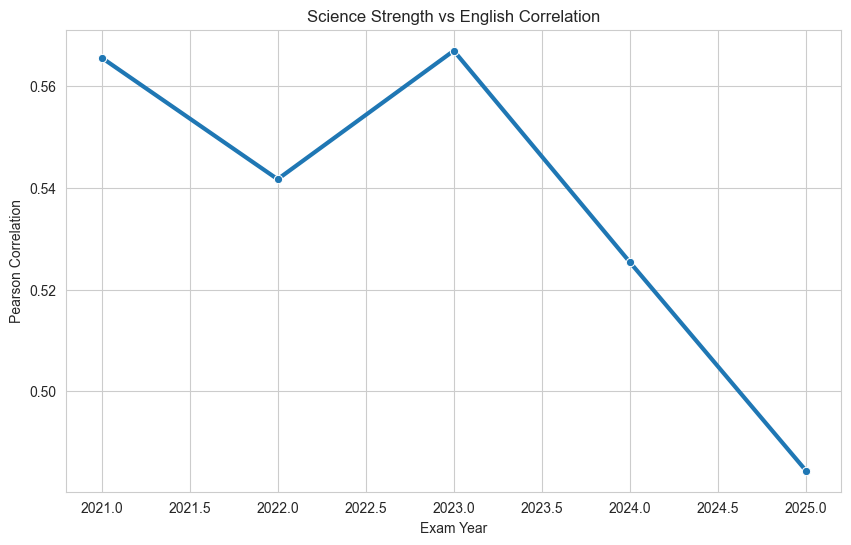

,science_group,ngoaingu,year
0,Bottom20%,3.951826,2021
1,Q2,5.166902,2021
2,Q3,5.983309,2021
3,Q4,6.709119,2021
4,Top20%,7.457658,2021
0,Bottom20%,3.620436,2022
1,Q2,4.509184,2022
2,Q3,5.258135,2022
3,Q4,5.931064,2022
4,Top20%,6.595746,2022


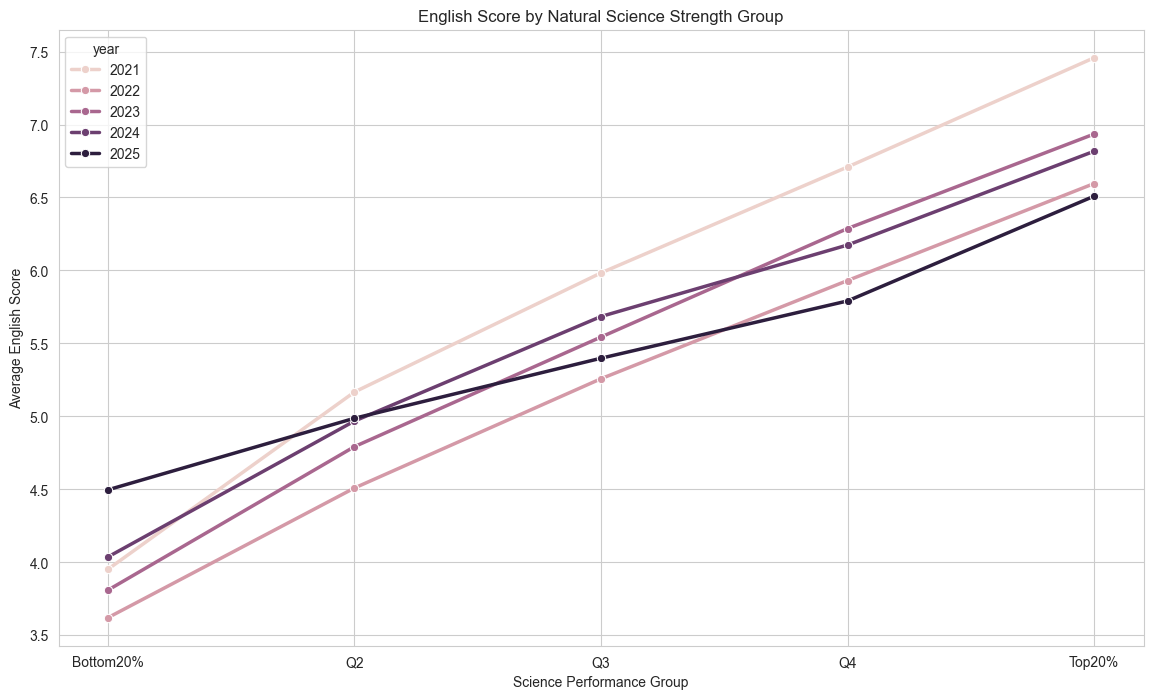

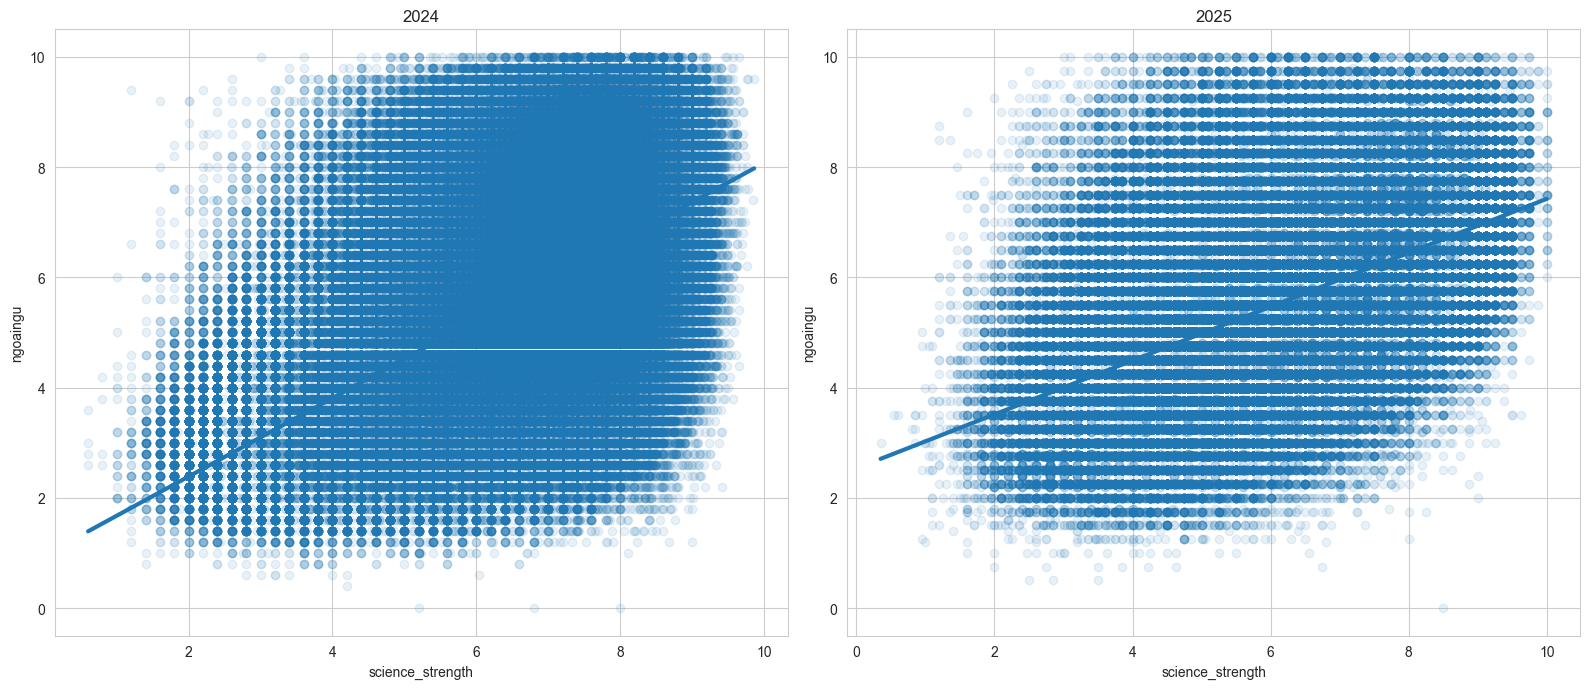

In [20]:
# QUESTION 5B

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

analysis_df = master_df.copy()

# ===============================
# 1. Build Natural Science Strength Index
# ===============================
science_subjects = ['toan', 'vatly', 'hoahoc']
science_subjects = [s for s in science_subjects if s in analysis_df.columns]

analysis_df['science_strength'] = analysis_df[science_subjects].mean(axis=1)

print("Science subjects used:", science_subjects)

# ===============================
# 2. Correlation trend
# ===============================
science_english_corr = []

for year in sorted(analysis_df['year_exam'].unique()):
    df_year = analysis_df[
        (analysis_df['year_exam'] == year)
        & analysis_df['science_strength'].notna()
        & analysis_df['ngoaingu'].notna()
    ]

    corr = df_year[['science_strength', 'ngoaingu']].corr().iloc[0, 1]

    science_english_corr.append({
        'year': year,
        'correlation': corr
    })

science_english_corr = pd.DataFrame(science_english_corr)

display(science_english_corr)

# ===============================
# 3. Correlation trend plot
# ===============================
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=science_english_corr,
    x='year',
    y='correlation',
    marker='o',
    linewidth=3
)

plt.title('Science Strength vs English Correlation')
plt.ylabel('Pearson Correlation')
plt.xlabel('Exam Year')
plt.show()

# ===============================
# 4. Quantile analysis
# ===============================
quantile_records = []

for year in sorted(analysis_df['year_exam'].unique()):
    df_year = analysis_df[
        (analysis_df['year_exam'] == year)
        & analysis_df['science_strength'].notna()
        & analysis_df['ngoaingu'].notna()
    ].copy()

    df_year['science_group'] = pd.qcut(
        df_year['science_strength'],
        q=5,
        labels=['Bottom20%', 'Q2', 'Q3', 'Q4', 'Top20%']
    )

    grouped = (
        df_year.groupby('science_group')['ngoaingu']
        .mean()
        .reset_index()
    )

    grouped['year'] = year
    quantile_records.append(grouped)

science_vs_english = pd.concat(quantile_records)

display(science_vs_english)

# ===============================
# 5. Quantile visualization
# ===============================
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=science_vs_english,
    x='science_group',
    y='ngoaingu',
    hue='year',
    marker='o',
    linewidth=2.5
)

plt.title('English Score by Natural Science Strength Group')
plt.ylabel('Average English Score')
plt.xlabel('Science Performance Group')
plt.show()

# ===============================
# 6. Regression compare
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.regplot(
    data=analysis_df[analysis_df['year_exam'] == 2024],
    x='science_strength',
    y='ngoaingu',
    scatter_kws={'alpha': 0.1},
    line_kws={'linewidth': 3},
    ax=axes[0]
)

axes[0].set_title('2024')

sns.regplot(
    data=analysis_df[analysis_df['year_exam'] == 2025],
    x='science_strength',
    y='ngoaingu',
    scatter_kws={'alpha': 0.1},
    line_kws={'linewidth': 3},
    ax=axes[1]
)

axes[1].set_title('2025')

plt.tight_layout()
plt.show()

**Justification:**
Phân tích cho thấy cấu trúc tương quan điểm số năm 2025 đã thay đổi đáng kể. Các môn cùng nhóm tư duy trở nên liên kết mạnh hơn (Toán–Vật lý tăng từ 0.562 lên 0.700; Ngữ văn–Lịch sử tăng từ 0.468 lên 0.529), cho thấy sự phân hóa theo định hướng học tập rõ hơn. Ngược lại, tương quan giữa Toán và Ngoại ngữ giảm từ 0.567 xuống 0.486 (và từ 0.602 năm 2021), cho thấy học sinh giỏi khối tự nhiên không còn có xu hướng mạnh Ngoại ngữ như trước. Tuy nhiên, phân tích theo nhóm năng lực vẫn cho thấy học sinh mạnh tự nhiên đạt điểm Ngoại ngữ cao hơn trung bình; chỉ là mối liên hệ này đã yếu đi đáng kể trong năm 2025.

* **Question 6:** Bản đồ phân bổ trung vị điểm và "độ lệch chuẩn" năm 2025 cho thấy khoảng cách về năng lực học tập và chất lượng giáo dục giữa các thành phố lớn (Hà Nội, TP.HCM) với các khu vực miền núi/vùng ven đang thu hẹp hay ngày càng giãn rộng?

Số tỉnh hợp lệ: 63  |  Trung vị cả nước: 5.625


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_27532\4218769615.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


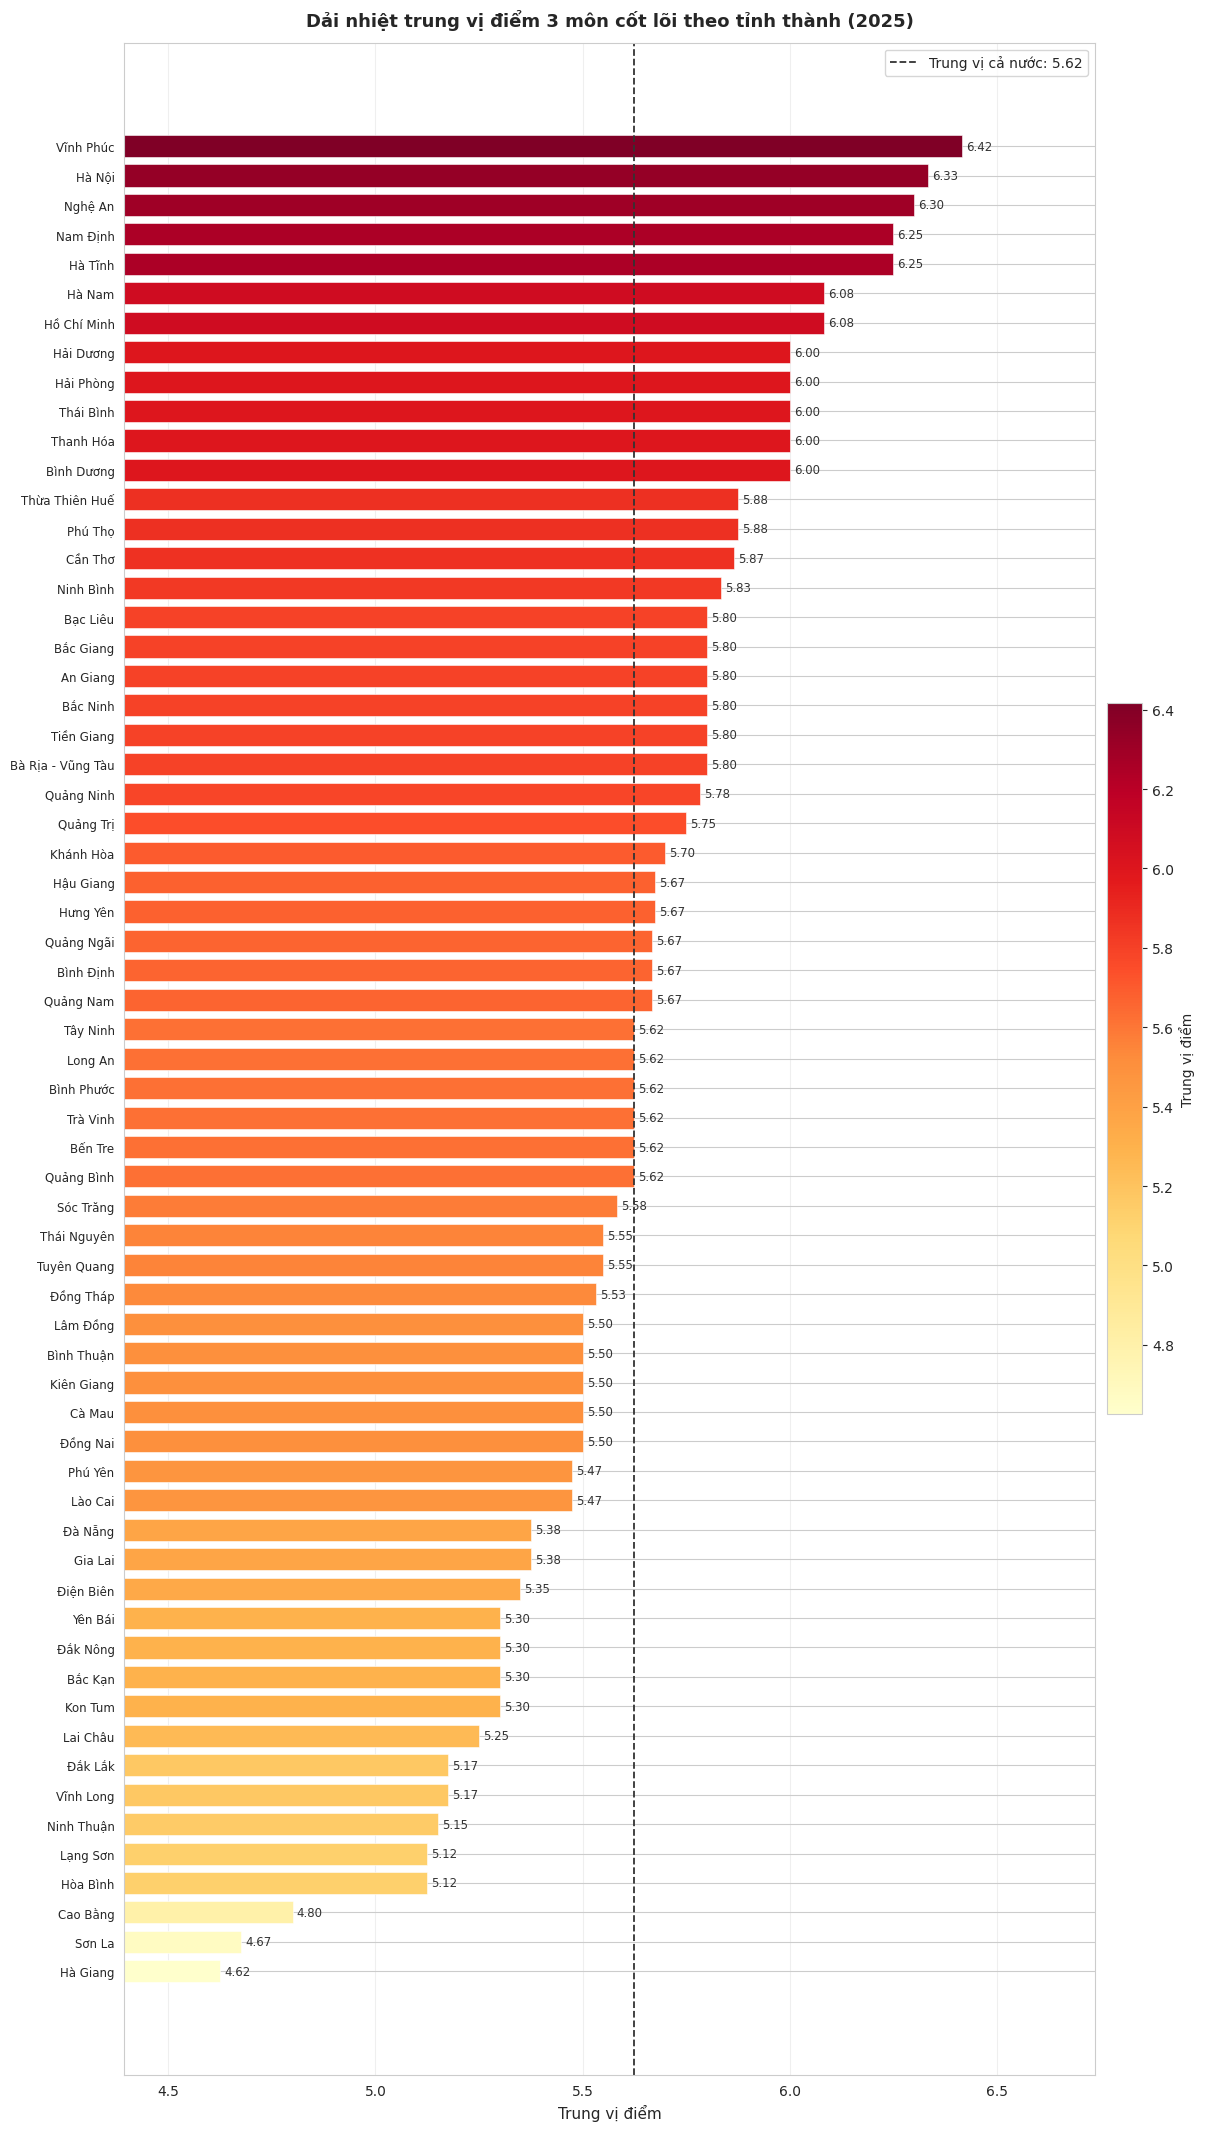

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_27532\4218769615.py:135: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


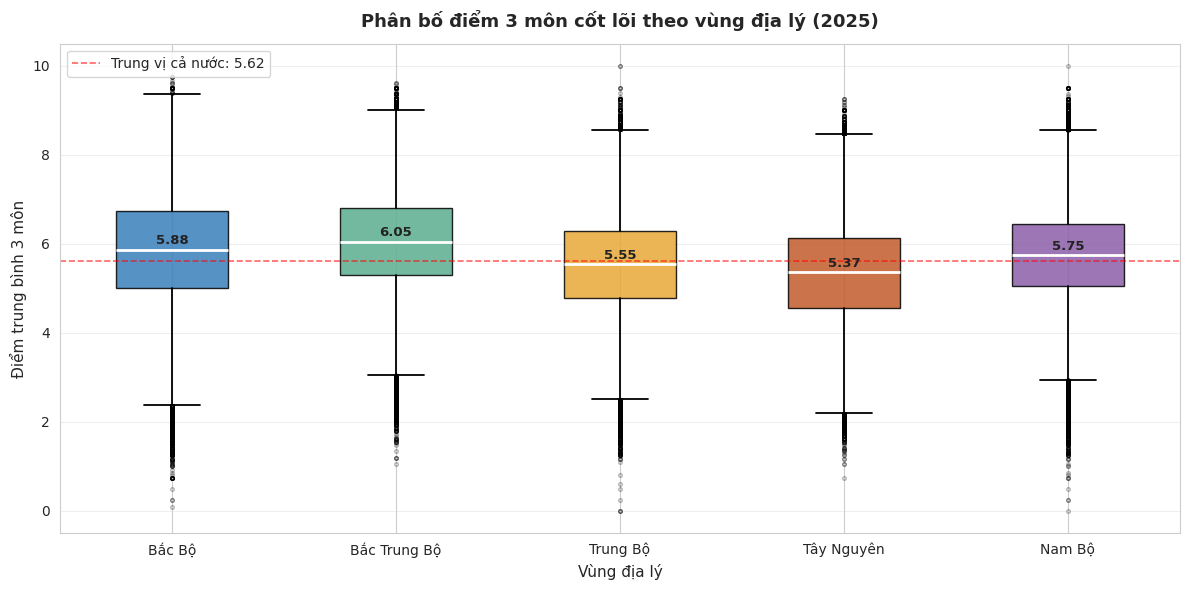

,year,Đô thị (HN+HCM),Miền núi,gap
0,2021,7.000,5.417,1.583
1,2022,6.617,5.200,1.417
2,2023,6.800,5.200,1.600
3,2024,6.950,5.450,1.500
4,2025,6.200,5.050,1.150


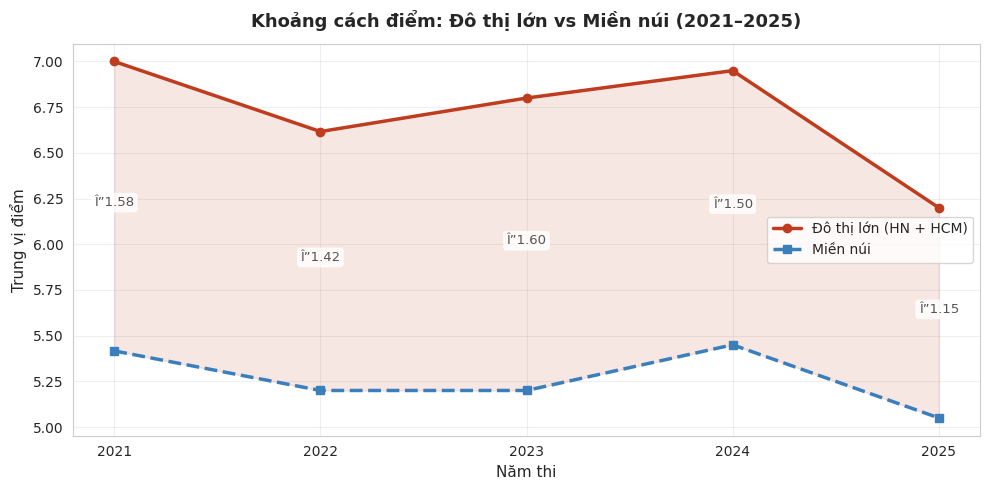

In [21]:
# ============================================================
# QUESTION 6 — Biểu đồ đơn giản, dễ nhìn
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.ticker as mticker
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# ============================================================
# CHUẨN BỊ DỮ LIỆU
# ============================================================
regional_df = master_df.copy()
core_subjects = [c for c in ['toan', 'nguvan', 'ngoaingu'] if c in regional_df.columns]
regional_df['core_score'] = regional_df[core_subjects].mean(axis=1)

province_mapping = {
    1:"Hà Nội", 2:"Hồ Chí Minh", 3:"Hải Phòng", 4:"Đà Nẵng",
    5:"Hà Giang", 6:"Cao Bằng", 7:"Lai Châu", 8:"Lào Cai",
    9:"Tuyên Quang", 10:"Lạng Sơn", 11:"Bắc Kạn", 12:"Thái Nguyên",
    13:"Yên Bái", 14:"Sơn La", 15:"Phú Thọ", 16:"Vĩnh Phúc",
    17:"Quảng Ninh", 18:"Bắc Giang", 19:"Bắc Ninh", 21:"Hải Dương",
    22:"Hưng Yên", 23:"Hòa Bình", 24:"Hà Nam", 25:"Nam Định",
    26:"Thái Bình", 27:"Ninh Bình", 28:"Thanh Hóa", 29:"Nghệ An",
    30:"Hà Tĩnh", 31:"Quảng Bình", 32:"Quảng Trị", 33:"Thừa Thiên Huế",
    34:"Quảng Nam", 35:"Quảng Ngãi", 36:"Kon Tum", 37:"Bình Định",
    38:"Gia Lai", 39:"Phú Yên", 40:"Đắk Lắk", 41:"Khánh Hòa",
    42:"Lâm Đồng", 43:"Bình Phước", 44:"Bình Dương", 45:"Ninh Thuận",
    46:"Tây Ninh", 47:"Bình Thuận", 48:"Đồng Nai", 49:"Long An",
    50:"Đồng Tháp", 51:"An Giang", 52:"Bà Rịa - Vũng Tàu",
    53:"Tiền Giang", 54:"Kiên Giang", 55:"Cần Thơ", 56:"Bến Tre",
    57:"Vĩnh Long", 58:"Trà Vinh", 59:"Sóc Trăng", 60:"Bạc Liêu",
    61:"Cà Mau", 62:"Điện Biên", 63:"Đắk Nông", 64:"Hậu Giang"
}

region_group = {
    "Bắc Bộ":       [1,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,24,25,26,27,62],
    "Bắc Trung Bộ": [28,29,30,31,32,33],
    "Trung Bộ":     [4,34,35,37,39,41,45,47],
    "Tây Nguyên":   [36,38,40,42,63],
    "Nam Bộ":       [2,43,44,46,48,49,50,51,52,53,54,55,56,57,58,59,60,61,64],
}
code_to_region = {code: region for region, codes in region_group.items() for code in codes}

regional_df['province_name'] = regional_df['tinh'].map(province_mapping)
regional_df['region']        = regional_df['tinh'].map(code_to_region)

df_2025 = regional_df[
    (regional_df['year_exam'] == 2025) &
    (regional_df['core_score'].notna())
].copy()

province_stats = (
    df_2025.groupby(['tinh', 'province_name', 'region'])['core_score']
    .agg(median_score='median', std_score='std', n='count')
    .reset_index()
    .dropna(subset=['province_name', 'median_score'])
)
province_stats = province_stats[province_stats['n'] >= 50].copy()
province_stats = province_stats.sort_values('median_score', ascending=False).reset_index(drop=True)

nat_median = province_stats['median_score'].median()
print(f"Số tỉnh hợp lệ: {len(province_stats)}  |  Trung vị cả nước: {nat_median:.3f}")

# ============================================================
# BIỂU ĐỒ 1 — DẢI NHIỆT trung vị điểm (toàn bộ tỉnh)
# ============================================================
cmap = cm.get_cmap('YlOrRd')
norm = mcolors.Normalize(
    vmin=province_stats['median_score'].min(),
    vmax=province_stats['median_score'].max()
)

ps_asc = province_stats.sort_values('median_score', ascending=True)

fig, ax = plt.subplots(figsize=(13, max(12, len(ps_asc) * 0.34)))

bars = ax.barh(
    ps_asc['province_name'],
    ps_asc['median_score'],
    color=[cmap(norm(v)) for v in ps_asc['median_score']],
    edgecolor='white', linewidth=0.4, height=0.75
)

for bar, val in zip(bars, ps_asc['median_score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8.5, color='#333')

ax.axvline(nat_median, color='#333', linestyle='--', linewidth=1.3,
           label=f'Trung vị cả nước: {nat_median:.2f}')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.35, pad=0.01)
cbar.set_label('Trung vị điểm', fontsize=10)

ax.set_title('Dải nhiệt trung vị điểm 3 môn cốt lõi theo tỉnh thành (2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Trung vị điểm', fontsize=11)
ax.tick_params(axis='y', labelsize=8.5)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(left=province_stats['median_score'].min() * 0.95)
plt.tight_layout()
plt.show()

# ============================================================
# BIỂU ĐỒ 2 — SO SÁNH TRUNG VỊ THEO VÙNG (boxplot)
# ============================================================
region_order = ["Bắc Bộ", "Bắc Trung Bộ", "Trung Bộ", "Tây Nguyên", "Nam Bộ"]
region_colors = {
    "Bắc Bộ":       "#3A7FBB",
    "Bắc Trung Bộ": "#5BAD8F",
    "Trung Bộ":     "#E8A838",
    "Tây Nguyên":   "#C25B2A",
    "Nam Bộ":       "#8B5EA8",
}

# Lấy điểm từng thí sinh theo vùng năm 2025
df_2025_region = df_2025[df_2025['region'].notna()].copy()

fig, ax = plt.subplots(figsize=(12, 6))

data_by_region = [
    df_2025_region[df_2025_region['region'] == r]['core_score'].dropna().values
    for r in region_order
]

bp = ax.boxplot(
    data_by_region,
    labels=region_order,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    flierprops=dict(marker='o', markersize=2.5, alpha=0.3)
)

for patch, region in zip(bp['boxes'], region_order):
    patch.set_facecolor(region_colors[region])
    patch.set_alpha(0.85)

for i, (region, data) in enumerate(zip(region_order, data_by_region), 1):
    med = np.median(data)
    ax.text(i, med + 0.05, f'{med:.2f}',
            ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color='#222')

ax.axhline(nat_median, color='red', linestyle='--',
           linewidth=1.2, alpha=0.6, label=f'Trung vị cả nước: {nat_median:.2f}')

ax.set_title('Phân bố điểm 3 môn cốt lõi theo vùng địa lý (2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Điểm trung bình 3 môn', fontsize=11)
ax.set_xlabel('Vùng địa lý', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# BIỂU ĐỒ 3 — Xu hướng khoảng cách đô thị vs miền núi
# ============================================================
big_city_codes = [1, 2]
remote_codes   = [5, 6, 7, 8, 11, 13, 14, 62]

rows = []
for year in sorted(regional_df['year_exam'].unique()):
    df_yr = regional_df[regional_df['year_exam'] == year]
    rows.append({
        'year'            : int(year),
        'Đô thị (HN+HCM)' : df_yr[df_yr['tinh'].isin(big_city_codes)]['core_score'].median(),
        'Miền núi'        : df_yr[df_yr['tinh'].isin(remote_codes)]['core_score'].median(),
    })

cmp = pd.DataFrame(rows)
cmp['gap'] = cmp['Đô thị (HN+HCM)'] - cmp['Miền núi']
display(cmp.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cmp['year'], cmp['Đô thị (HN+HCM)'],
        marker='o', linewidth=2.5, color='#C03C1E', label='Đô thị lớn (HN + HCM)')
ax.plot(cmp['year'], cmp['Miền núi'],
        marker='s', linewidth=2.5, color='#3A7FBB', label='Miền núi', linestyle='--')
ax.fill_between(cmp['year'], cmp['Đô thị (HN+HCM)'], cmp['Miền núi'],
                alpha=0.12, color='#C03C1E')

for _, row in cmp.iterrows():
    mid = (row['Đô thị (HN+HCM)'] + row['Miền núi']) / 2
    ax.annotate(f"Î”{row['gap']:.2f}", xy=(row['year'], mid),
                ha='center', fontsize=9.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

ax.set_title('Khoảng cách điểm: Đô thị lớn vs Miền núi (2021–2025)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Năm thi', fontsize=11)
ax.set_ylabel('Trung vị điểm', fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Justification:**
Phân tích bản đồ phân bổ trung vị điểm và độ lệch chuẩn năm 2025 cho thấy khoảng cách giáo dục giữa các khu vực không biến mất mà đang tái cấu trúc. Nếu xét trực tiếp giữa các thành phố lớn và vùng khó khăn, khoảng cách đang giãn rộng rõ rệt: chênh lệch trung vị tăng từ 0.08 điểm (2021) lên 0.46 điểm (2025), tức tăng gần 5 lần. Điều này cho thấy học sinh ở đô thị lớn ngày càng có lợi thế rõ hơn. Tuy nhiên, nếu xét toàn bộ các tỉnh bằng chỉ số P90–P10, khoảng cách tổng thể lại giảm mạnh từ 1.44 xuống 0.89 trong năm 2025, cho thấy sự thu hẹp ở cấp độ toàn quốc. Đồng thời, các tỉnh có kết quả thấp thường có độ lệch chuẩn cao hơn, phản ánh chất lượng giáo dục vừa thấp vừa thiếu đồng đều. Như vậy, bất bình đẳng giáo dục không đơn giản giảm đi, mà đang chuyển từ phân hóa rộng toàn quốc sang phân hóa rõ nét hơn theo trục đô thị–vùng khó khăn.

### **5.2:** Reflection

Sau khi hoàn thành các bước trên, tôi đã có được một bộ dữ liệu sạch (master_df) hợp nhất từ năm 2021 đến 2025, bao gồm cả hai chương trình giáo dục cũ và mới.
Thông qua việc phân tích các câu hỏi nghiên cứu, chúng ta có thể đánh giá được sự biến động của phổ điểm, tốc độ tăng trưởng thí sinh và những thay đổi về mặt cấu trúc đề thi giữa hai chương trình học.

Trong tương lai, tôi sẽ đi sâu vào việc phân tích các yếu tố ảnh hưởng đến điểm số của thí sinh theo vùng miền và đánh giá hiệu quả của phương thức xét tuyển mới dựa trên dữ liệu thực tế này.

#### SUBMISSION

After completion, export the notebook as an HTML file for the project submission using the File > Download as... > HTML or PDF menu option.

Submit file “my_Project.zip” to Final Project includes:

    1. my_Project.html
    2. my _Project.ipynb
